# Exploratory Data Analysis (EDA): Spotify Music Recommendation

## 1. Project Objectives
The goal of this project is to build a music recommendation system that, given one or more input songs, suggests a list of tracks the user is most likely to enjoy next. 

For the recommendation model, we selected features that describe the sound, mood, musical structure, lyrical characteristics, genre context, and popularity of each track.
The main features used for similarity are:
- acousticness
- danceability
- energy
- instrumentalness
- liveness
- loudness
- speechiness
- tempo
- valence


### 1.1. EDA
This notebook conducts an extensive **Exploratory Data Analysis (EDA)** to evaluate the Spotify dataset for building a content-based music recommendation system. The analysis focuses on:

1. Examining the quality and completeness of the main recommendation features, including audio, lyrical, genre, and popularity-related variables.
2. Exploring the distributions of key audio features such as danceability, energy, acousticness, instrumentalness, loudness, tempo, speechiness, and valence.
3. Investigating artist and genre patterns to understand how musical context can support similarity-based recommendations.

## 2. Setup & Data Loading

In [20]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load environment and config (force refresh)
load_dotenv(project_root / '.env', override=True)
from soeSpotify import config

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
palette = sns.color_palette("viridis", as_cmap=False)

print("Setup complete.")

Setup complete.


In [21]:
print("Loading analytical datasets...")

# We use the analytics stage data as it is already cleaned and joined
df_tracks = pd.read_parquet(config.ANALYTICS_TRACKS)
df_artists = pd.read_parquet(config.ANALYTICS_ARTISTS)
df_genres = pd.read_parquet(config.ANALYTICS_GENRES)
df_features = pd.read_parquet(config.ANALYTICS_TRACK_FEATURES)

print(f"Tracks loaded:   {len(df_tracks):,}")
print(f"Artists loaded:  {len(df_artists):,}")
print(f"Genres loaded:   {len(df_genres):,}")
print(f"Features loaded: {len(df_features):,}")

Loading analytical datasets...
Tracks loaded:   101,144
Artists loaded:  56,129
Genres loaded:   87,202
Features loaded: 101,144


Check to see the distribution of tracks marked as "podcast" and the ones that should be normal songs.

In [22]:
podcast_summary = pd.DataFrame({
    "count": df_tracks["is_podcast"].value_counts(),
    "percentage": df_tracks["is_podcast"].value_counts(normalize=True).mul(100).round(2)
})

podcast_summary


,count,percentage
is_podcast,,
no,93823,92.76
yes,7321,7.24


Check to see how my features split my data podcast vs. normal tracks.

In [23]:
audio_features = [
    "duration_ms",
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "time_signature",
    "valence"
]

artist_features = [
    "track_popularity",
    "artist_popularity",
    "artist_followers"
]

text_features = [
    "mean_syllables_word",
    "mean_words_sentence",
    "n_sentences",
    "n_words",
    "sentence_similarity",
    "vocabulary_wealth"
]

categorical_features = [
    "album_type",
    "artist_primary_genre_broad",
    "artist_secondary_genre_broad"
]

numeric_features = audio_features + artist_features + text_features
summary_mean = df_tracks.groupby("is_podcast")[numeric_features].mean().T
summary_median = df_tracks.groupby("is_podcast")[numeric_features].median().T

podcast_comparison = summary_mean.join(
    summary_median,
    lsuffix="_mean",
    rsuffix="_median"
)

podcast_comparison

is_podcast,no_mean,yes_mean,no_median,yes_median
duration_ms,229248.938267,470050.492829,216843.000000,218347.000000
acousticness,0.327824,0.645597,0.201000,0.702000
danceability,0.585502,0.593654,0.606000,0.633000
energy,0.604665,0.365860,0.646000,0.312000
instrumentalness,0.153914,0.079979,0.000063,0.000000
liveness,0.187737,0.322184,0.121000,0.229000
loudness,-8.846014,-16.984384,-7.303000,-17.127000
speechiness,0.081714,0.720090,0.048200,0.888000
tempo,119.487926,104.351344,119.931000,99.599000
time_signature,3.900067,3.572599,4.000000,4.000000


The summary statistics show clear differences between podcast and non-podcast tracks. 
Podcast-labelled tracks are much more speech-heavy, with a median speechiness of 0.888 compared with 0.048 for non-podcasts. They are also quieter, less energetic, and more acoustic. 

Although podcast tracks have a higher mean duration, their median duration is similar to non-podcast tracks, suggesting that the podcast group contains a mixture of long recordings and shorter segmented spoken-content tracks (which is to be expected since we also removed some tracks ad-hoc). 
Text-based features also support the separation: podcast tracks have substantially more words and higher vocabulary wealth. 

Overall, the created podcast label appears plausible and captures tracks with strong spoken-audio characteristics.

## One-Class SVM

One-Class SVM was used to learn the feature pattern of tracks labelled as podcasts. The trained model was then applied to tracks labelled as non-podcasts to identify tracks that showed similar characteristics to the podcast group. These tracks were treated as possible missed podcasts or non-music tracks and inspected further.

In [24]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import OneClassSVM

# Prepare features
features = numeric_features + categorical_features

numeric_features = [col for col in numeric_features if col in df_tracks.columns]
categorical_features = [col for col in categorical_features if col in df_tracks.columns]
features = numeric_features + categorical_features

df_yes = df_tracks[df_tracks["is_podcast"] == "yes"].copy()
df_no = df_tracks[df_tracks["is_podcast"] == "no"].copy()

print("Known podcasts:", df_yes.shape[0])
print("Marked non-podcasts:", df_no.shape[0])

# Preprocess features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

X_yes = preprocessor.fit_transform(df_yes[features])
X_no = preprocessor.transform(df_no[features])

# Train One-Class SVM only on known podcasts
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.6
)

ocsvm.fit(X_yes)

# Prediction:
#  1 = similar to podcast group
# -1 = not similar to podcast group
df_no["ocsvm_prediction"] = ocsvm.predict(X_no)

# Higher score = more podcast-like
df_no["ocsvm_score"] = ocsvm.decision_function(X_no)

# Extract possible missed podcasts
possible_missed_podcasts_ocsvm = df_no[
    df_no["ocsvm_prediction"] == 1
].sort_values("ocsvm_score", ascending=False)

candidate_cols = [
    "track_id",
    "track_name",
    "artist_name",
    "album_name",
    "genres",
    "artist_primary_genre",
    "artist_primary_genre_broad",
    "artist_secondary_genre_broad",
    "is_podcast",
    "ocsvm_prediction",
    "ocsvm_score",
    "duration_ms",
    "speechiness",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "n_words",
    "vocabulary_wealth",
    "track_popularity",
    "artist_popularity",
    "artist_followers"
]

candidate_cols = [col for col in candidate_cols if col in possible_missed_podcasts_ocsvm.columns]

print("Possible missed podcasts using One-Class SVM:", possible_missed_podcasts_ocsvm.shape[0])



Known podcasts: 7321
Marked non-podcasts: 93823
Possible missed podcasts using One-Class SVM: 666


Different values of the One-Class SVM parameter nu were tested to control how many non-podcast tracks were flagged as podcast-like. Lower nu values were too broad and classified a large share of the non-podcast group as similar to podcasts. For example, nu=0.05 flagged 82.85% of the non-podcast tracks, which was not useful for manual inspection. As nu increased, the model became more selective. The value nu=0.60 flagged only 666 tracks, representing 0.71% of the non-podcast group. Therefore, nu=0.60 was selected because it produced a small and manageable set of high-priority candidates for further manual review.

In [25]:
possible_missed_podcasts_ocsvm[candidate_cols].head(5)

,track_id,track_name,artist_name,album_name,genres,artist_primary_genre,artist_primary_genre_broad,artist_secondary_genre_broad,is_podcast,ocsvm_prediction,...,speechiness,energy,loudness,acousticness,instrumentalness,n_words,vocabulary_wealth,track_popularity,artist_popularity,artist_followers
46324,7LIMVYx5Xqfs8zBLwgB7eX,Folge 122: Inferno in der Alptraum-Schlucht. T...,John Sinclair,Folge 122: Inferno in der Alptraum-Schlucht. T...,"['hoerspiel', 'kleine hoerspiel', 'reading']",hoerspiel,house,classical,no,1,...,0.487,0.546,-16.280,0.400,0.000000,470.0,0.67,19,58,25097
31078,7nFV4iJ1JmMt4EmyB8yePO,Folge 121: Die Geburt des Schwarzen Tods. Teil...,John Sinclair,Folge 121: Die Geburt des Schwarzen Tods. Teil...,"['hoerspiel', 'kleine hoerspiel', 'reading']",hoerspiel,house,classical,no,1,...,0.486,0.429,-14.352,0.435,0.000000,470.0,0.67,19,58,25097
35435,6iqoDOuXWIIh1eg01gWDba,A Voz,Kivitz,Em Nome do Vento,['rap cristao'],rap cristao,hip hop,,no,1,...,0.406,0.533,-12.489,0.539,0.000000,587.0,0.74,29,43,9239
1270,1Mmb3qPr6kp2vUN3lkMDWB,126 - und die gefährlichen Wurzeln - Teil 17,Fünf Freunde,126/und die gefährlichen Wurzeln,['hoerspiel'],hoerspiel,house,,no,1,...,0.498,0.451,-10.891,0.378,0.000000,82.0,0.63,28,69,51804
19672,7DdkzSh2ErysNbgf4gFVzs,"Folge 117: Zombies auf dem Roten Platz, Kapitel 5",John Sinclair,Folge 117: Zombies auf dem Roten Platz,"['hoerspiel', 'kleine hoerspiel', 'reading']",hoerspiel,house,classical,no,1,...,0.429,0.473,-16.953,0.435,0.000009,470.0,0.67,21,58,25097


### Plausability check
Check to see if the tracks marked as possible podcasts are plausible.

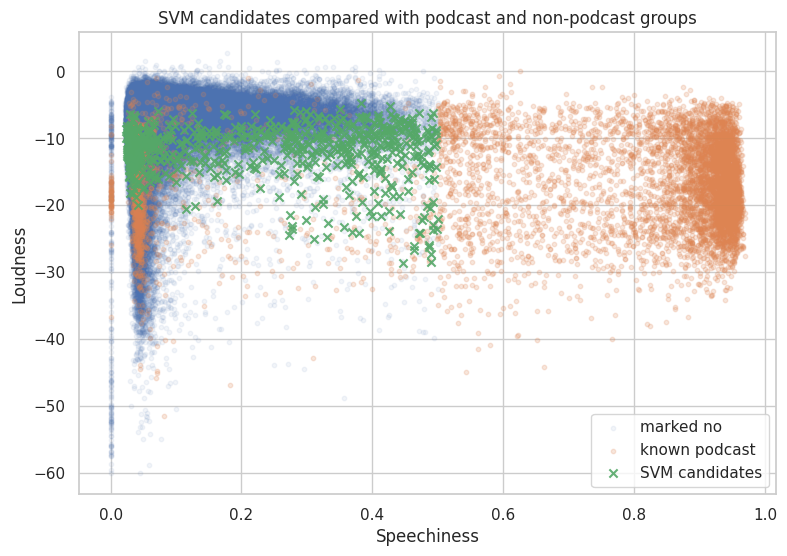

In [26]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_tracks[df_tracks["is_podcast"] == "no"]["speechiness"],
    df_tracks[df_tracks["is_podcast"] == "no"]["loudness"],
    alpha=0.07,
    s=10,
    label="marked no"
)

plt.scatter(
    df_tracks[df_tracks["is_podcast"] == "yes"]["speechiness"],
    df_tracks[df_tracks["is_podcast"] == "yes"]["loudness"],
    alpha=0.20,
    s=10,
    label="known podcast"
)

plt.scatter(
    possible_missed_podcasts_ocsvm["speechiness"],
    possible_missed_podcasts_ocsvm["loudness"],
    alpha=0.9,
    s=35,
    marker="x",
    label="SVM candidates"
)

plt.xlabel("Speechiness")
plt.ylabel("Loudness")
plt.title("SVM candidates compared with podcast and non-podcast groups")
plt.legend()
plt.show()

The plot shows that the SVM candidates are located mainly in the overlap between non-podcast tracks and known podcasts, especially at moderate speechiness and lower loudness. This suggests that the model is identifying borderline tracks that share podcast-like audio characteristics and should be reviewed manually before relabelling.

The possible missed tracks are further inspected ad-hoc.

In [27]:
import re

spoken_keyword_list = [
    r"\bintroduction to\b",
    r"\bbuddhism\b",
    r"\bfolge\s*\d+",
    r"\bteil\s*\d+",
    r"\bkapitel\s*\d+",
    r"\bchapter\s*\d+",
    r"\bpart\s*\d+",
    r"\blesson\s*\d+",
    r"hörspiel",
    r"hoerspiel",
    r"audiobook",
    r"audio book",
    r"self help audio books",
    r"bedtime stories",
    r"fairy tales",
    r"slam poetry",
    r"poetry collection",
    r"narrated by",
    r"reading her poetry",
    r"read in french",
    r"vocabulearn",
    r"learn in your car",
    r"present tense patterns",
    r"\bar verbs\b",
    r"\ber verbs\b",
    r"\bir verbs\b",
    r"john sinclair",
    r"fünf freunde",
    r"funf freunde",
    r"die drei !!!",
    r"die drei \?\?\?",
    r"hanni und nanni",
    r"tkkg",
    r"teufelskicker",
    r"der kleine prinz",
    r"shel silverstein",
    r"jack kerouac",
    r"jean vilar",
    r"paul a\. mankin",
    r"sylvia plath",
    r"dylan thomas",
    r"langston hughes",
    r"william shakespeare",
    r"shakespeare",
    r"john keats",
    r"malcolm x",
    r"tabaluga",
    r"käpt'n sharky",
    r"kaept'n sharky",
    r"petit ours brun",
    r"emily dickinson",
    r"english romantic poetry",
    r"selected readings",
    r"bhagavad gita",
    r"speeches & poems",
    r"revolutionary speeches",
    r"john s\. martin",
    r"samuel b\. charters",
    r"christopher isherwood",
    r"michael macliammoir",
    r"the letters of emily dickinson",
    r"selected readings from the bhagavad",
    r"minuto com deus",
    r"devocionais",
    r"judith anderson",
    r"a child's garden of verses",
    r"lewis carroll",
    r"nonsense verse",
    r"john s\. martin",
    r"english romantic poetry",
    r"sir john gielgud",
    r"william shakespeare's hamlet",
    r"pablo neruda",
    r"samuel b\. charters",
    r"emily dickinson",
    r"christopher isherwood",
    r"selected readings from the bhagavad",
    r"bhagavad gita",
    r"michael macliammoir",
    r"revolutionary speeches",
    r"speeches & poems",
    r"benjamin blümchen",
    r"benjamin bluemchen",
    r"käpt'n sharky",
    r"kaept'n sharky",
    r"petit ours brun",
    r"bamse",
    r"pastor edvaldo oliveira",
    r"minuto com deus",
    r"devocionais",
    r"margaret cho",
    r"garfunkel and oates",
    r"peter sellers",
    r"emi comedy"
]

spoken_keywords = "|".join(spoken_keyword_list)

possible_missed_podcasts_ocsvm = possible_missed_podcasts_ocsvm.copy()

text_for_check = (
    possible_missed_podcasts_ocsvm["track_name"].fillna("").str.lower()
    + " "
    + possible_missed_podcasts_ocsvm["artist_name"].fillna("").str.lower()
    + " "
    + possible_missed_podcasts_ocsvm["album_name"].fillna("").str.lower()
    + " "
    + possible_missed_podcasts_ocsvm["genres"].astype(str).fillna("").str.lower()
)

possible_missed_podcasts_ocsvm["review_category"] = "needs_manual_review"

possible_missed_podcasts_ocsvm.loc[
    text_for_check.str.contains(spoken_keywords, regex=True, na=False),
    "review_category"
] = "very_likely_non_music"

possible_missed_podcasts_ocsvm["review_category"].value_counts()

review_category
needs_manual_review      544
very_likely_non_music    122
Name: count, dtype: int64

Check which words matched.

In [28]:
matches = []

for keyword in spoken_keyword_list:
    count = text_for_check.str.contains(keyword, regex=True, na=False).sum()
    if count > 0:
        matches.append({"keyword": keyword, "matched_rows": count})

keyword_match_summary = (
    pd.DataFrame(matches)
    .sort_values("matched_rows", ascending=False)
)

#keyword_match_summary

Mark the 122 found tracks as "podcast"  in our dataset.

In [29]:
podcast_summary = pd.DataFrame({
    "count_before_SVM": df_tracks["is_podcast"].value_counts(),
    "percentage_before_SVM": df_tracks["is_podcast"].value_counts(normalize=True).mul(100).round(2)
})

podcast_summary

,count_before_SVM,percentage_before_SVM
is_podcast,,
no,93823,92.76
yes,7321,7.24


In [30]:
# Get track_ids that were classified as very likely non-music
very_likely_non_music_ids = possible_missed_podcasts_ocsvm.loc[
    possible_missed_podcasts_ocsvm["review_category"] == "very_likely_non_music",
    "track_id"
]

# Mark them as podcasts in df_tracks
df_tracks.loc[
    df_tracks["track_id"].isin(very_likely_non_music_ids),
    "is_podcast"
] = "yes"

podcast_summary = pd.DataFrame({
    "count_after_SVM": df_tracks["is_podcast"].value_counts(),
    "percentage_after_SVM": df_tracks["is_podcast"].value_counts(normalize=True).mul(100).round(2)
})

podcast_summary

,count_after_SVM,percentage_after_SVM
is_podcast,,
no,93701,92.64
yes,7443,7.36


## Genre clustering

In this step we imputed the genre for tracks missing it, based on the clustering of different broad genres by features.

In [31]:
# Work only with music tracks
df_music = df_tracks[df_tracks["is_podcast"] == "no"].copy()

target_genre_col = "artist_primary_genre_broad"

# Define missing broad genre
missing_genre_mask = (
    df_music[target_genre_col].isna()
    | (df_music[target_genre_col].astype(str).str.strip() == "")
)

df_known_genre = df_music[~missing_genre_mask].copy()
df_missing_genre = df_music[missing_genre_mask].copy()

print("Known broad genre tracks:", df_known_genre.shape[0])
print("Missing broad genre tracks:", df_missing_genre.shape[0])

genre_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence"
]

genre_features = [col for col in genre_features if col in df_tracks.columns]

genre_profiles = (
    df_known_genre
    .groupby(target_genre_col)[genre_features]
    .mean()
    .dropna()
)

genre_profiles

Known broad genre tracks: 76956
Missing broad genre tracks: 16745


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
artist_primary_genre_broad,,,,,,,,,
blues,0.403677,0.583786,0.592687,0.106603,0.193655,-8.976738,0.067227,119.004741,0.574792
classical,0.528458,0.500277,0.462428,0.275342,0.178391,-13.119653,0.060482,116.045873,0.428575
electronic,0.386995,0.578305,0.552502,0.383058,0.174323,-11.320432,0.071665,117.562008,0.388695
folk,0.462793,0.549170,0.533596,0.087602,0.184822,-9.334981,0.055380,120.073613,0.511386
hip hop,0.249961,0.669208,0.651235,0.125611,0.180544,-7.677411,0.144822,119.154933,0.540086
house,0.160634,0.666406,0.719696,0.265820,0.193556,-7.305929,0.084282,122.643294,0.460763
indie,0.348266,0.546154,0.580358,0.126564,0.175476,-8.657985,0.057035,120.164289,0.455154
jazz,0.401897,0.617669,0.570702,0.239709,0.180820,-9.064135,0.073572,119.943097,0.574257
metal,0.163047,0.502485,0.787850,0.111965,0.232446,-6.366550,0.083069,125.474911,0.455896


The genre profiles show that broad genres differ in their average audio characteristics. Genres such as house, hip hop, and metal are generally more energetic and louder, while classical is more acoustic, quieter, and more instrumental. Hip hop has the highest speechiness, and house has one of the highest danceability values. These patterns support using audio-feature similarity to estimate missing broad genre labels.

To extract the information regarding genres, we used the distances from the nearest neighbours. Genres were extracted only for tracks that were missing one.

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

df_missing_for_match = df_missing_genre.dropna(subset=genre_features).copy()

scaler = StandardScaler()

X_genres = scaler.fit_transform(genre_profiles[genre_features])
X_missing = scaler.transform(df_missing_for_match[genre_features])

nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(X_genres)

distances, indices = nn.kneighbors(X_missing)

df_missing_for_match["predicted_artist_primary_genre_broad"] = genre_profiles.index[indices.flatten()]
df_missing_for_match["genre_match_distance"] = distances.flatten()
df_missing_for_match["genre_match_score"] = 1 / (1 + df_missing_for_match["genre_match_distance"])

df_missing_for_match[
    [
        "track_name",
        "artist_name",
        target_genre_col,
        "predicted_artist_primary_genre_broad",
        "genre_match_score",
        "genre_match_distance"
    ]
].sort_values("genre_match_score", ascending=False).head(10)

,track_name,artist_name,artist_primary_genre_broad,predicted_artist_primary_genre_broad,genre_match_score,genre_match_distance
25642,Funky Feelings,LIVI,,blues,0.330819,2.022798
82458,Deixa Eu Te Encontrar,Julia Sicone,,folk,0.287395,2.479537
84786,Pra Tua Glória,Novidade de Vida Music,,metal,0.278867,2.585944
78840,Poncho Konos,T3R Elemento,,pop,0.278166,2.594970
92095,Un Antes y un Después,Marcelo Ezquiaga,,pop,0.276839,2.612202
10031,"Mä annan sut pois (Tähdet, tähdet kausi 5)",Jussi Rainio,,world,0.275529,2.629384
32836,הבלדה על חדווה ושלומיק,Miri Aloni,,metal,0.268220,2.728289
60,ADORO BOLOS,Conan Osíris,,world,0.266941,2.746150
89338,A New Mission,Josh Whitehouse,,pop,0.262416,2.810745
27154,Changed My Ways,Murray A. Lightburn,,blues,0.262178,2.814195


In [35]:
df_missing_for_match["predicted_artist_primary_genre_broad"].value_counts()

predicted_artist_primary_genre_broad
r&b           2885
metal         2555
classical     2446
hip hop       1651
house         1134
world         1114
electronic    1047
pop           1004
jazz           816
indie          746
blues          532
rock           469
folk           346
Name: count, dtype: int64

In [36]:
# Backup original column first
df_tracks["artist_primary_genre_broad_original"] = df_tracks["artist_primary_genre_broad"]

# Map predicted genres by track_id
prediction_map = df_missing_for_match.set_index("track_id")[
    "predicted_artist_primary_genre_broad"
]

# Define rows where broad genre is missing
missing_mask = (
    df_tracks["artist_primary_genre_broad"].isna()
    | (df_tracks["artist_primary_genre_broad"].astype(str).str.strip() == "")
)

# Override only missing values
df_tracks.loc[
    missing_mask & df_tracks["track_id"].isin(prediction_map.index),
    "artist_primary_genre_broad"
] = df_tracks.loc[
    missing_mask & df_tracks["track_id"].isin(prediction_map.index),
    "track_id"
].map(prediction_map)

# Mark imputed rows
df_tracks["genre_broad_was_imputed"] = (
    missing_mask & df_tracks["track_id"].isin(prediction_map.index)
)

# Check result
df_tracks["genre_broad_was_imputed"].value_counts()

genre_broad_was_imputed
False    84399
True     16745
Name: count, dtype: int64

# 2.1. Overall feature quality checks

In [3]:
print("Analytics Tracks Shape:")
print(f"Rows: {df_tracks.shape[0]:,}")
print(f"Columns: {df_tracks.shape[1]:,}")

# Audio features selected for the recommendation model
recommendation_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
]

# Metadata columns used only for identifying/displaying recommended tracks
metadata_columns = [
    "track_id",
    "track_name",
    "artist_name",
    "album_name",
    "uri",
    "preview_url",
    "release_date",
]

# Check which selected features are available in the dataset
available_features = [
    col for col in recommendation_features
    if col in df_tracks.columns
]

missing_features = [
    col for col in recommendation_features
    if col not in df_tracks.columns
]

print("\nAvailable recommendation features:")
print(available_features)

print("\nMissing recommendation features:")
print(missing_features)

# Summary of selected recommendation features
feature_quality = pd.DataFrame({
    "feature": available_features,
    "data_type": [df_tracks[col].dtype for col in available_features],
    "missing_count": [df_tracks[col].isna().sum() for col in available_features],
    "missing_percent": [df_tracks[col].isna().mean() * 100 for col in available_features],
    "zero_count": [(df_tracks[col] == 0).sum() for col in available_features],
    "zero_percent": [(df_tracks[col] == 0).mean() * 100 for col in available_features],
    "unique_values": [df_tracks[col].nunique(dropna=True) for col in available_features],
})

feature_quality["missing_percent"] = feature_quality["missing_percent"].round(2)
feature_quality["zero_percent"] = feature_quality["zero_percent"].round(2)

display(feature_quality.sort_values("missing_percent", ascending=False))

Analytics Tracks Shape:
Rows: 94,065
Columns: 37

Available recommendation features:
['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

Missing recommendation features:
[]


,feature,data_type,missing_count,missing_percent,zero_count,zero_percent,unique_values
0,acousticness,float64,0,0.0,52,0.06,4702
1,danceability,float64,0,0.0,362,0.38,1182
2,energy,float64,0,0.0,31,0.03,2309
3,instrumentalness,float64,0,0.0,30067,31.96,5374
4,liveness,float64,0,0.0,120,0.13,1717
5,loudness,float64,0,0.0,1,0.00,20222
6,speechiness,float64,0,0.0,362,0.38,1214
7,tempo,float64,0,0.0,362,0.38,47744
8,valence,float64,0,0.0,368,0.39,1770


In [4]:
#  Check duplicate tracks
duplicate_track_ids = df_tracks["track_id"].duplicated().sum()

print("\nDuplicate track_id count:")
print(duplicate_track_ids)


# Check essential metadata needed for recommendations
essential_columns = [
    "track_id",
    "track_name",
    "artist_name",
]

available_essential_columns = [
    col for col in essential_columns
    if col in df_tracks.columns
]

missing_essential_columns = [
    col for col in essential_columns
    if col not in df_tracks.columns
]

print("\nAvailable essential metadata columns:")
print(available_essential_columns)

print("\nMissing essential metadata columns:")
print(missing_essential_columns)

essential_quality = pd.DataFrame({
    "column": available_essential_columns,
    "missing_count": [
        df_tracks[col].isna().sum()
        for col in available_essential_columns
    ],
    "missing_percent": [
        df_tracks[col].isna().mean() * 100
        for col in available_essential_columns
    ],
})

essential_quality["missing_percent"] = essential_quality["missing_percent"].round(2)

print("\nEssential metadata quality:")
display(essential_quality)




Duplicate track_id count:
0

Available essential metadata columns:
['track_id', 'track_name', 'artist_name']

Missing essential metadata columns:
[]

Essential metadata quality:


,column,missing_count,missing_percent
0,track_id,0,0.0
1,track_name,0,0.0
2,artist_name,0,0.0


In [5]:
# Summary for selected audio recommendation features
numeric_features = [
    col for col in available_features
    if pd.api.types.is_numeric_dtype(df_tracks[col])
]

numeric_summary = df_tracks[numeric_features].describe().T

numeric_summary["missing_count"] = df_tracks[numeric_features].isna().sum()
numeric_summary["missing_percent"] = (
    df_tracks[numeric_features].isna().mean() * 100
).round(2)

display(numeric_summary)


# Check zero values in selected audio recommendation features
zero_summary = pd.DataFrame({
    "feature": numeric_features,
    "zero_count": [
        (df_tracks[col] == 0).sum()
        for col in numeric_features
    ],
    "zero_percent": [
        (df_tracks[col] == 0).mean() * 100
        for col in numeric_features
    ],
})

zero_summary["zero_percent"] = zero_summary["zero_percent"].round(2)

display(zero_summary.sort_values("zero_percent", ascending=False))



,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent
acousticness,94065.0,0.328108,0.328606,0.0,0.0338,0.202000,0.5880,0.996,0,0.0
danceability,94065.0,0.585123,0.179512,0.0,0.4750,0.606000,0.7180,0.989,0,0.0
energy,94065.0,0.603922,0.251494,0.0,0.4440,0.645000,0.8050,1.000,0,0.0
instrumentalness,94065.0,0.153939,0.307925,0.0,0.0000,0.000063,0.0462,1.000,0,0.0
liveness,94065.0,0.187590,0.163773,0.0,0.0943,0.121000,0.2240,0.999,0,0.0
loudness,94065.0,-8.864364,5.736376,-60.0,-10.3290,-7.311000,-5.3720,2.719,0,0.0
speechiness,94065.0,0.082025,0.082916,0.0,0.0357,0.048200,0.0853,0.599,0,0.0
tempo,94065.0,119.410463,29.871572,0.0,97.1590,119.925000,137.1110,244.035,0,0.0
valence,94065.0,0.486618,0.263843,0.0,0.2710,0.481000,0.7010,0.993,0,0.0


,feature,zero_count,zero_percent
3,instrumentalness,30067,31.96
8,valence,368,0.39
1,danceability,362,0.38
6,speechiness,362,0.38
7,tempo,362,0.38
4,liveness,120,0.13
0,acousticness,52,0.06
2,energy,31,0.03
5,loudness,1,0.00


The selected audio features are complete, with no missing values and no missing feature columns, making them suitable for a content-based recommendation model. The dataset also has no duplicate track_id values, and essential metadata is almost fully complete, with only one missing artist_name. Some zero values appear in features such as instrumentalness, which is expected because many songs are not instrumental.

Important: All features should be scaled before similarity modeling because the features are measured on different ranges.

## 3. Univariate Analysis: Understanding Individual Features

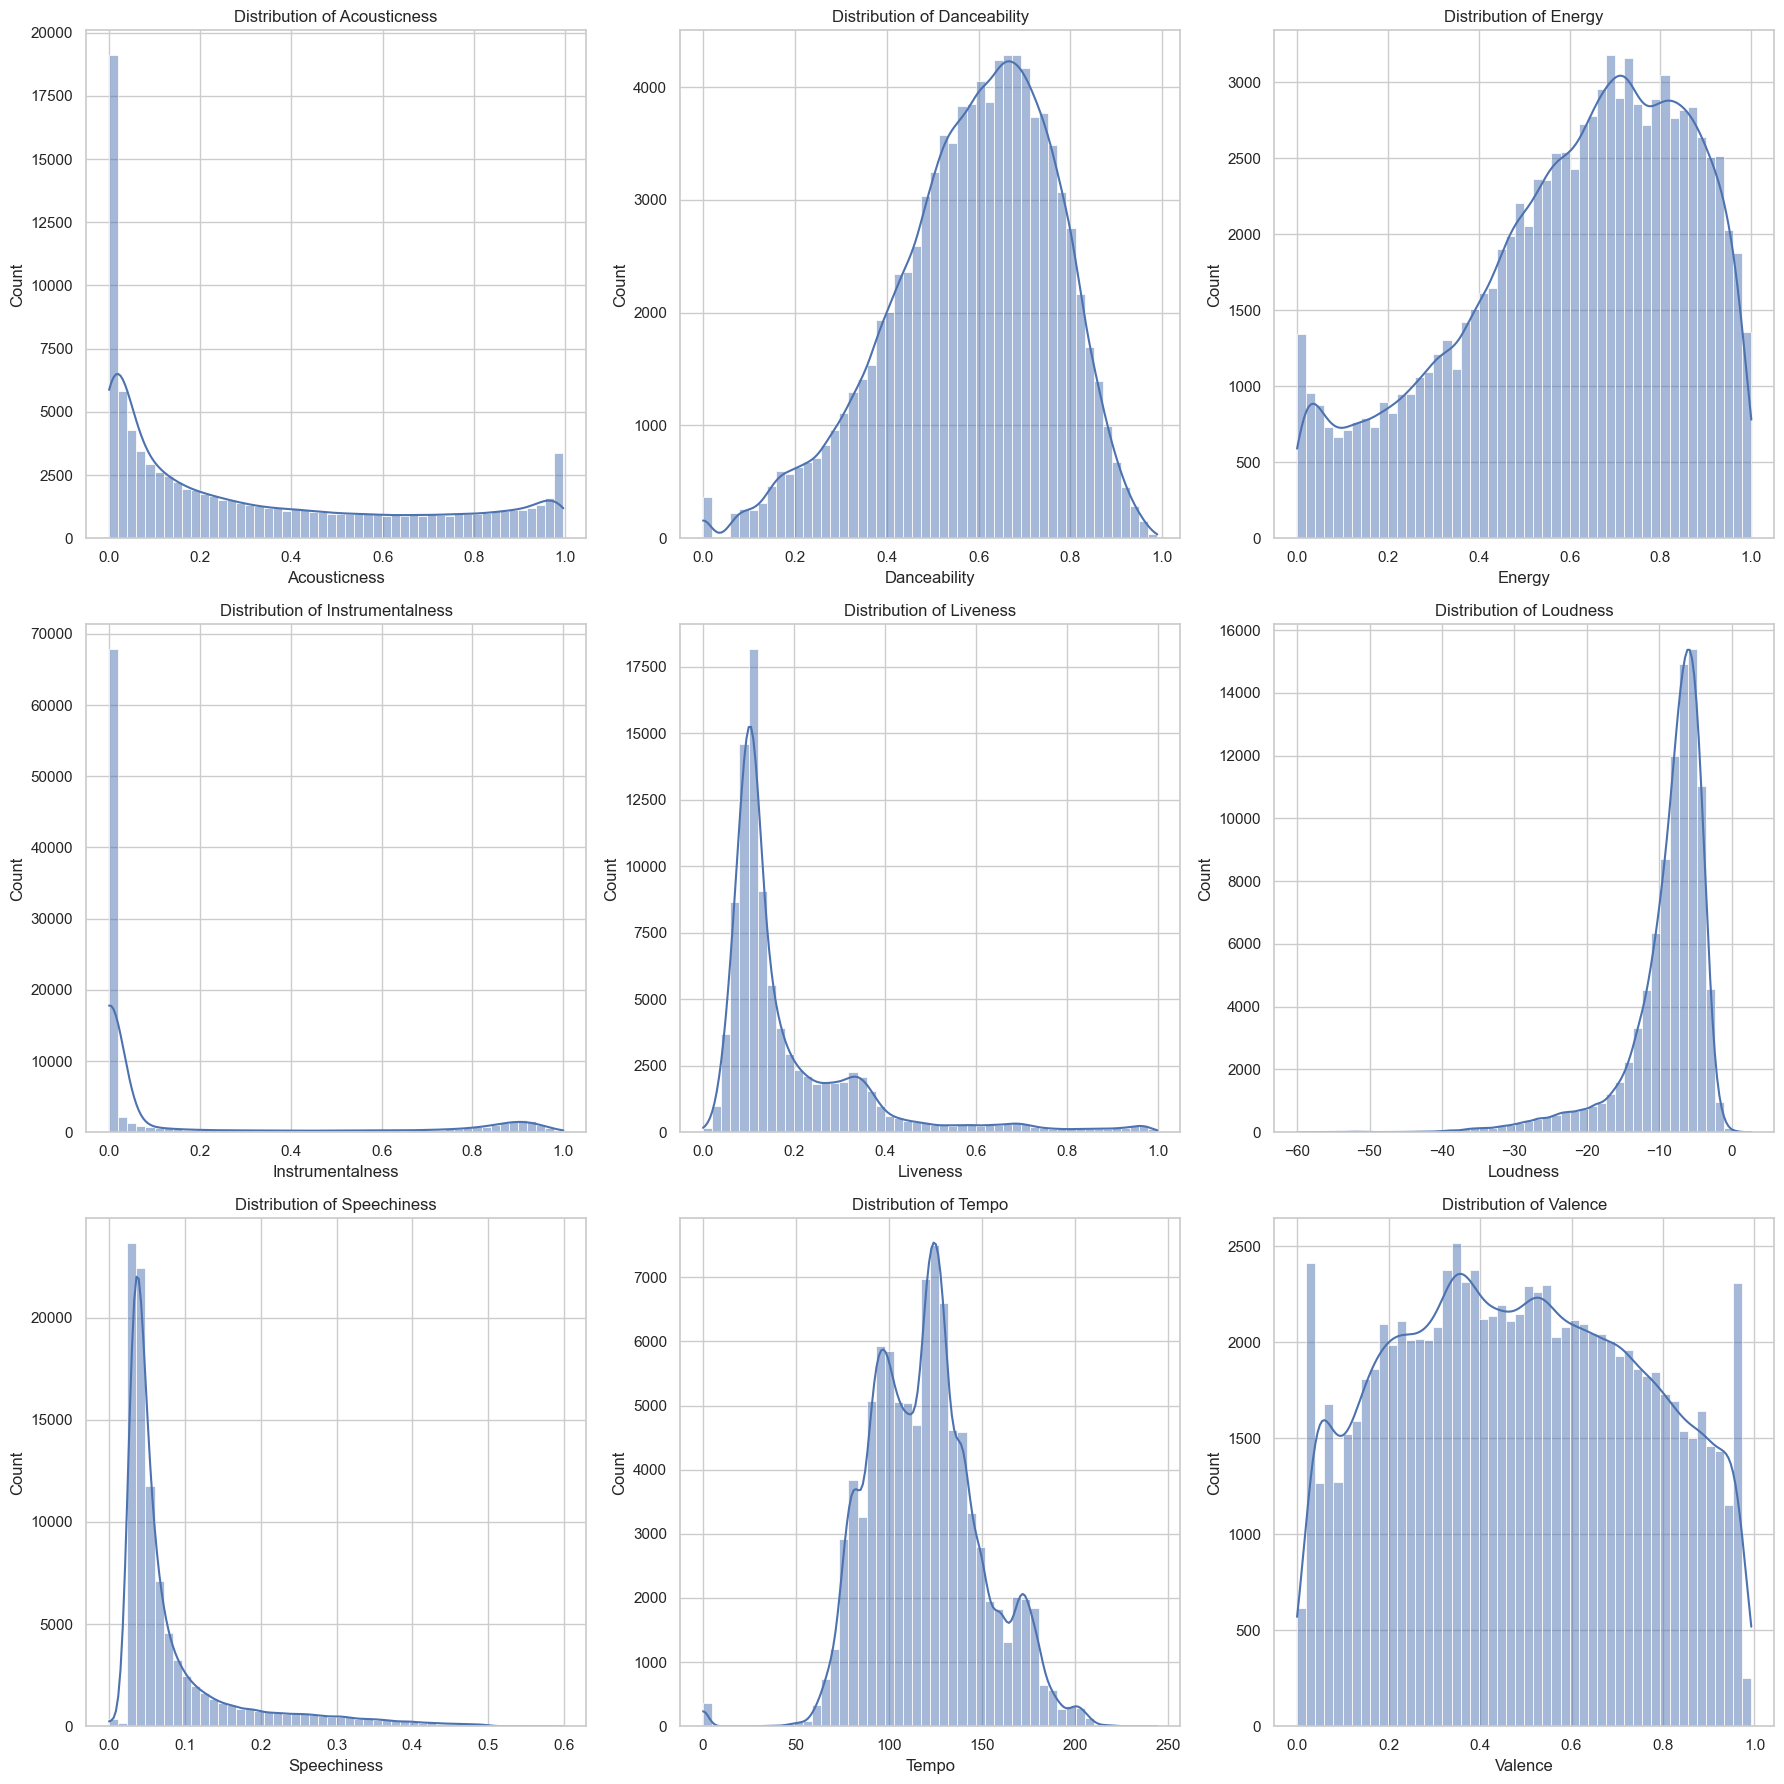

In [6]:
selected_audio_features = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
]

if not df_tracks.empty:
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.flatten()

    for i, feature in enumerate(selected_audio_features):
        sns.histplot(
            df_tracks[feature].dropna(),
            bins=50,
            kde=True,
            ax=axes[i]
        )

        axes[i].set_title(f"Distribution of {feature.replace('_', ' ').title()}")
        axes[i].set_xlabel(feature.replace("_", " ").title())
        axes[i].set_ylabel("Count")

    for j in range(len(selected_audio_features), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

else:
    print("No tracks data available.")

- **Acousticness**: Most tracks have low acousticness, meaning the dataset contains many tracks that sound less natural or live then tracks that sound more amplified. There is also a smaller group of highly acoustic tracks near 1.0.
- **Danceability**: Danceability is mostly concentrated between 0.4 and 0.8, showing that many tracks are moderately to highly danceable.
- **Energy**: Energy is generally high, with many songs between 0.5 and 0.9, suggesting the dataset contains many intense or active tracks.
- **Instrumentalness**: Most tracks have instrumentalness close to 0, meaning they likely contain vocals. Only a smaller group appears to be highly instrumental.
- **Liveness**: Most songs have low liveness values, meaning they are likely studio recordings rather than live performances.
- **Loudness**: Loudness is concentrated around higher values, roughly between -12 and -4 dB, with fewer very quiet tracks.
- **Speechiness**: Most tracks have low speechiness, meaning they are mostly musical rather than spoken-word or rap-heavy. This column was also used to filter out non music tracks, so all values above 0.6 have been eliminated
- **Tempo**: Tempo is centered mostly around 90–150 BPM, with clear peaks around common popular music tempos.
- **Valence**: Valence is spread across the full range, meaning the dataset contains both sad/darker and happy/positive sounding songs.

Overall the graphs show that the dataset consists mainly of studio-produced, vocal-based tracks, with generally low acousticness, instrumentalness, liveness, and speechiness. At the same time, many songs are moderately to highly danceable and energetic, with a wide range of emotional tone shown by the spread of valence values.

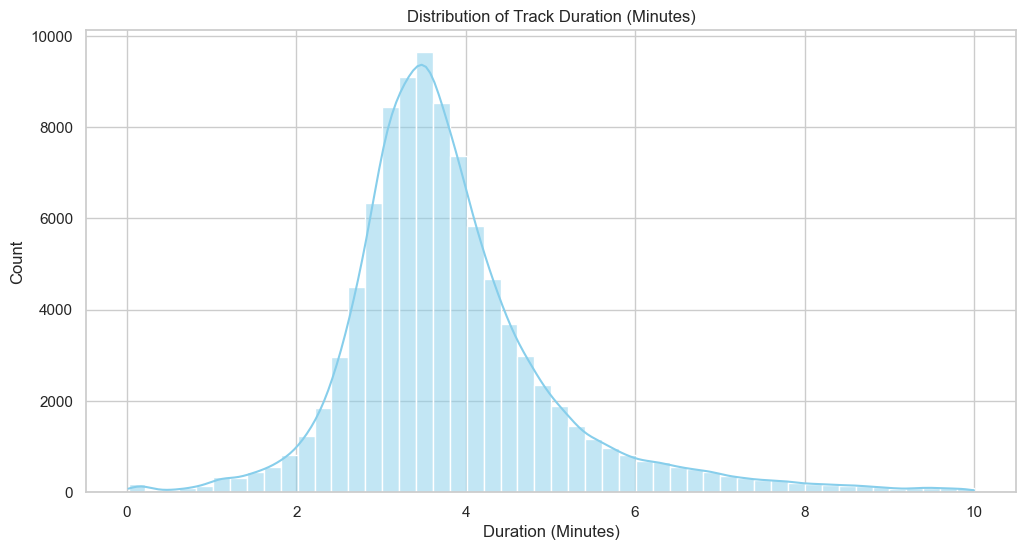

In [23]:

if not df_tracks.empty:
    df_tracks["duration_minutes"] = df_tracks["duration_ms"] / 60000
    sns.histplot(df_tracks["duration_minutes"].dropna(), bins=50, kde=True, color='skyblue')
    plt.title('Distribution of Track Duration (Minutes)')
    plt.xlabel('Duration (Minutes)')
    plt.ylabel('Count')
    plt.show()
else:
    print("No tracks data available.")

We see the majority of tracks are around 3, little over 3 minutes, which is the standard duration of modern music tracks. A strict cutoff at 10 minutes is coming from the preprocessing, where we attempt to eliminate non music tracks.

## 4. Bivariate & Multivariate Analysis

### 4.1. Audio Feature Correlations
Understanding which features move together.

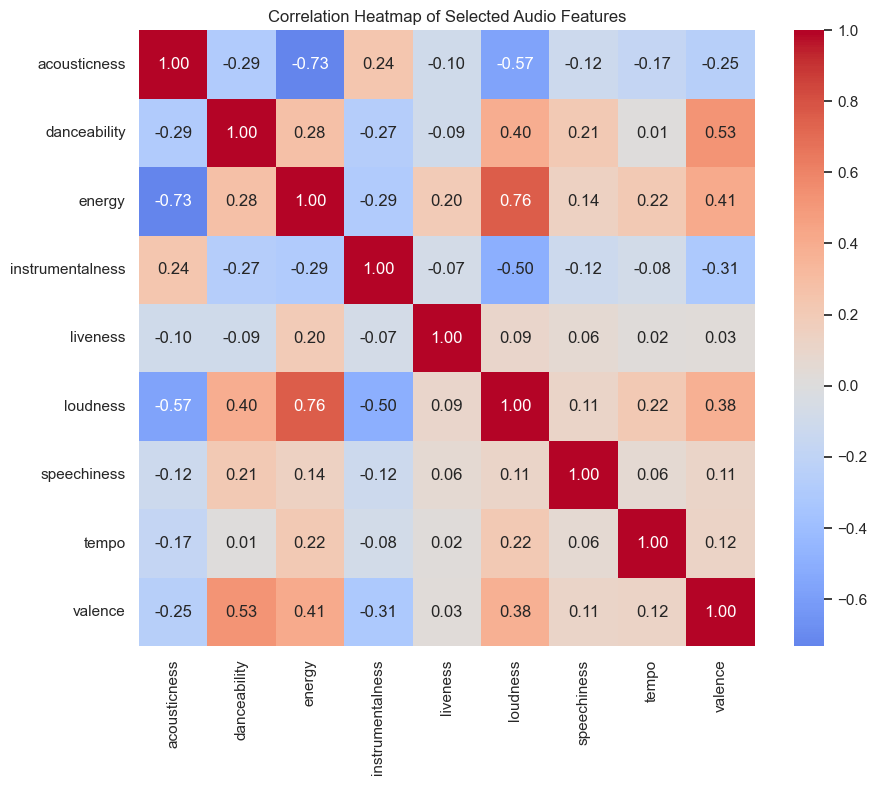

In [7]:
df_audio = df_tracks[selected_audio_features].copy()
plt.figure(figsize=(10, 8))

corr_matrix = df_audio.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap of Selected Audio Features")
plt.show()

The strongest features that move together positively are:
- energy + loudness: 0.76
- danceability + valence: 0.53
- energy + valence: 0.41
- loudness + valence: 0.38
- danceability + loudness: 0.40

This means that louder songs tend to be more energetic it is. More danceable songs tend to sound more positive/happy and higher-energy songs also tend to have higher valence.

The strongest features that move in opposite directions are:
- acousticness + energy: -0.73
- acousticness + loudness: -0.57
- instrumentalness + loudness: -0.50
- instrumentalness + valence: -0.31
- danceability + instrumentalness: -0.27

This means that more acoustic songs tend to be less energetic and quieter, while more instrumental tracks tend to be less loud, less danceable, and slightly less positive. 

Overall, the clearest relationship is that energy and loudness strongly move together, while acousticness moves strongly against energy and loudness.

### 4.2. Energy vs. Loudness vs. Acousticness


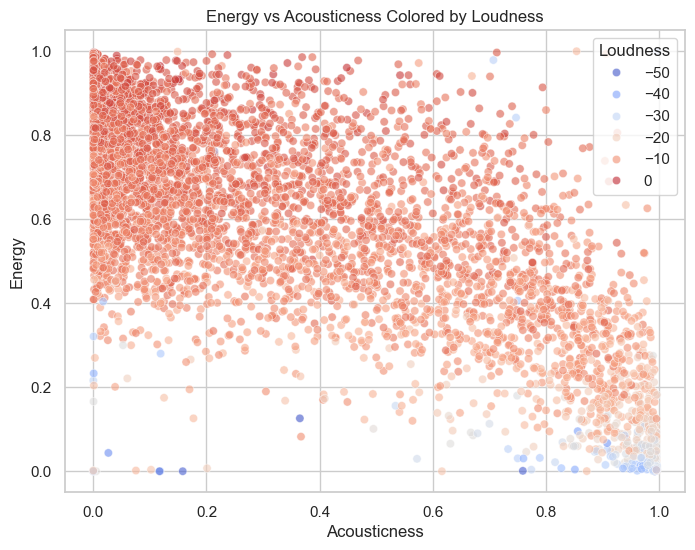

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_tracks.sample(5000, random_state=1000),
    x="acousticness",
    y="energy",
    hue="loudness",
    palette="coolwarm",
    alpha=0.6
)

plt.title("Energy vs Acousticness Colored by Loudness")
plt.xlabel("Acousticness")
plt.ylabel("Energy")
plt.legend(title="Loudness")
plt.show()

The plot shows that tracks with low acousticness cover a wide range of energy levels, but many of them are highly energetic. As acousticness increases, the density of high-energy tracks becomes lower, suggesting that more acoustic songs are generally less energetic, while louder tracks tend to appear more often in the higher-energy areas.

### 4.3. Energy vs. Valence (Mood Mapping)
This visualisation shows the information regarding mood mapping: high energy + high valence = Happy/Excited; high energy + low valence = Angry/Stressed.

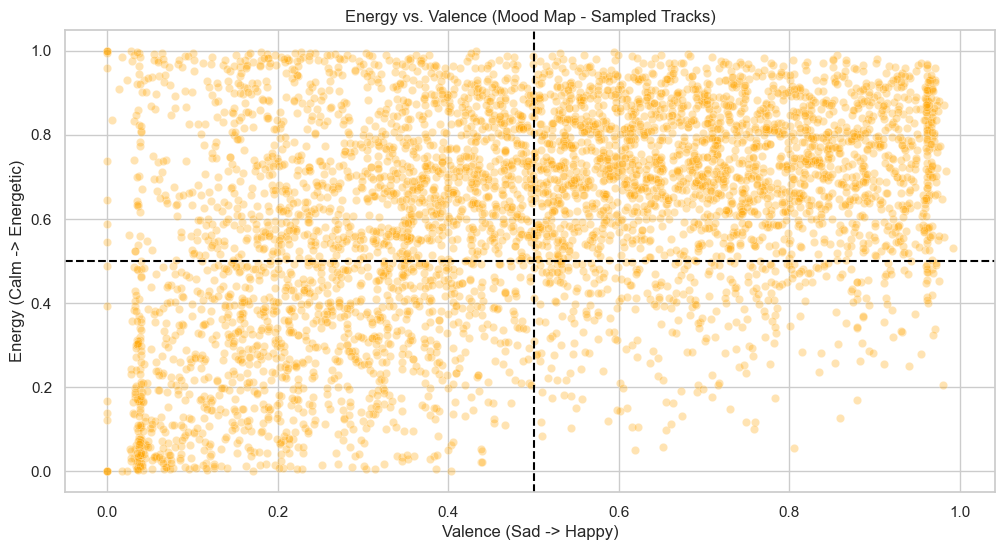

In [9]:
if not df_features.empty:
    sns.scatterplot(data=df_features.sample(n=min(5000, len(df_features))), x='valence', y='energy', alpha=0.3, color='orange')
    plt.axhline(0.5, color='black', linestyle='--')
    plt.axvline(0.5, color='black', linestyle='--')
    plt.title('Energy vs. Valence (Mood Map - Sampled Tracks)')
    plt.xlabel('Valence (Sad -> Happy)')
    plt.ylabel('Energy (Calm -> Energetic)')
    plt.show()
else:
    print("No features data available.")

This plot shows that the dataset contains tracks across all mood types, from low-valence “sadder” songs to high-valence “happier” songs, and from calm to energetic tracks. The upper-right area is especially dense, suggesting many songs are both energetic and relatively positive in mood.

## 5. Genre & Artist Analysis

### 5.1. Top 10 Genres
Identify the most frequent genres in our track dataset.

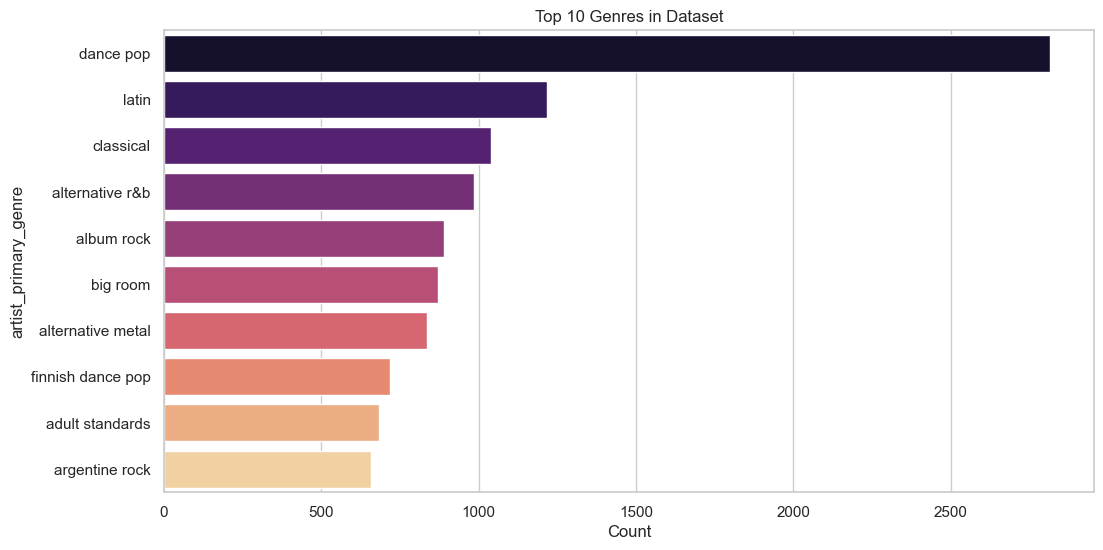

In [15]:
if not df_tracks.empty:
    genre_counts = df_tracks['artist_primary_genre'].dropna()
    genre_counts = genre_counts[genre_counts.astype(str).str.strip() != ""]
    top_genres = genre_counts.value_counts().head(10)
    sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='magma', legend=False)
    plt.title('Top 10 Genres in Dataset')
    plt.xlabel('Count')
    plt.show()
else:
    print("No genre data available.")


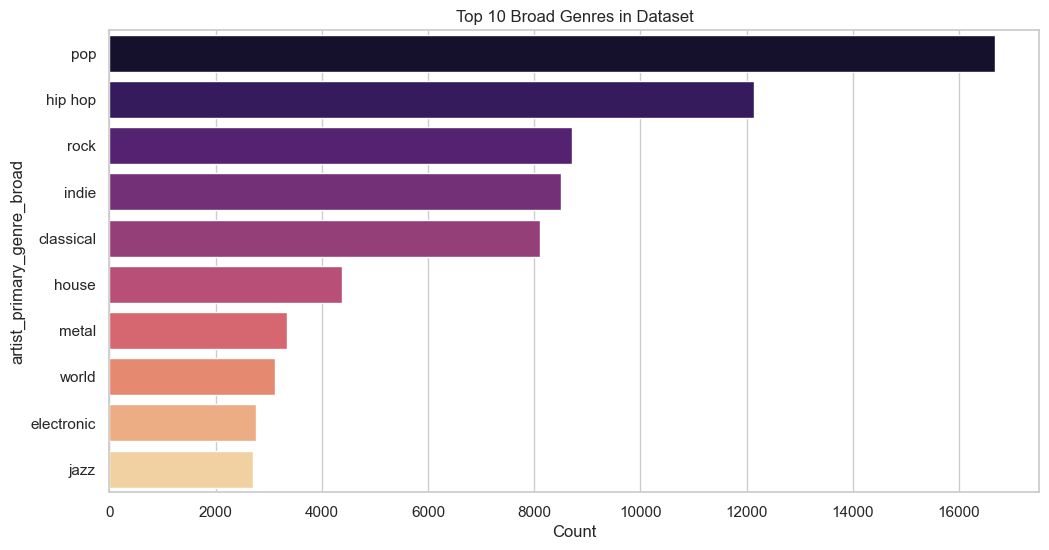

In [18]:
if not df_tracks.empty:
    genre_counts = df_tracks['artist_primary_genre_broad'].dropna()
    genre_counts = genre_counts[genre_counts.astype(str).str.strip() != ""]
    top_genres = genre_counts.value_counts().head(10)
    sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='magma', legend=False)
    plt.title('Top 10 Broad Genres in Dataset')
    plt.xlabel('Count')
    plt.show()
else:
    print("No genre data available.")

### 5.2. Top 10 artists by number of tracks

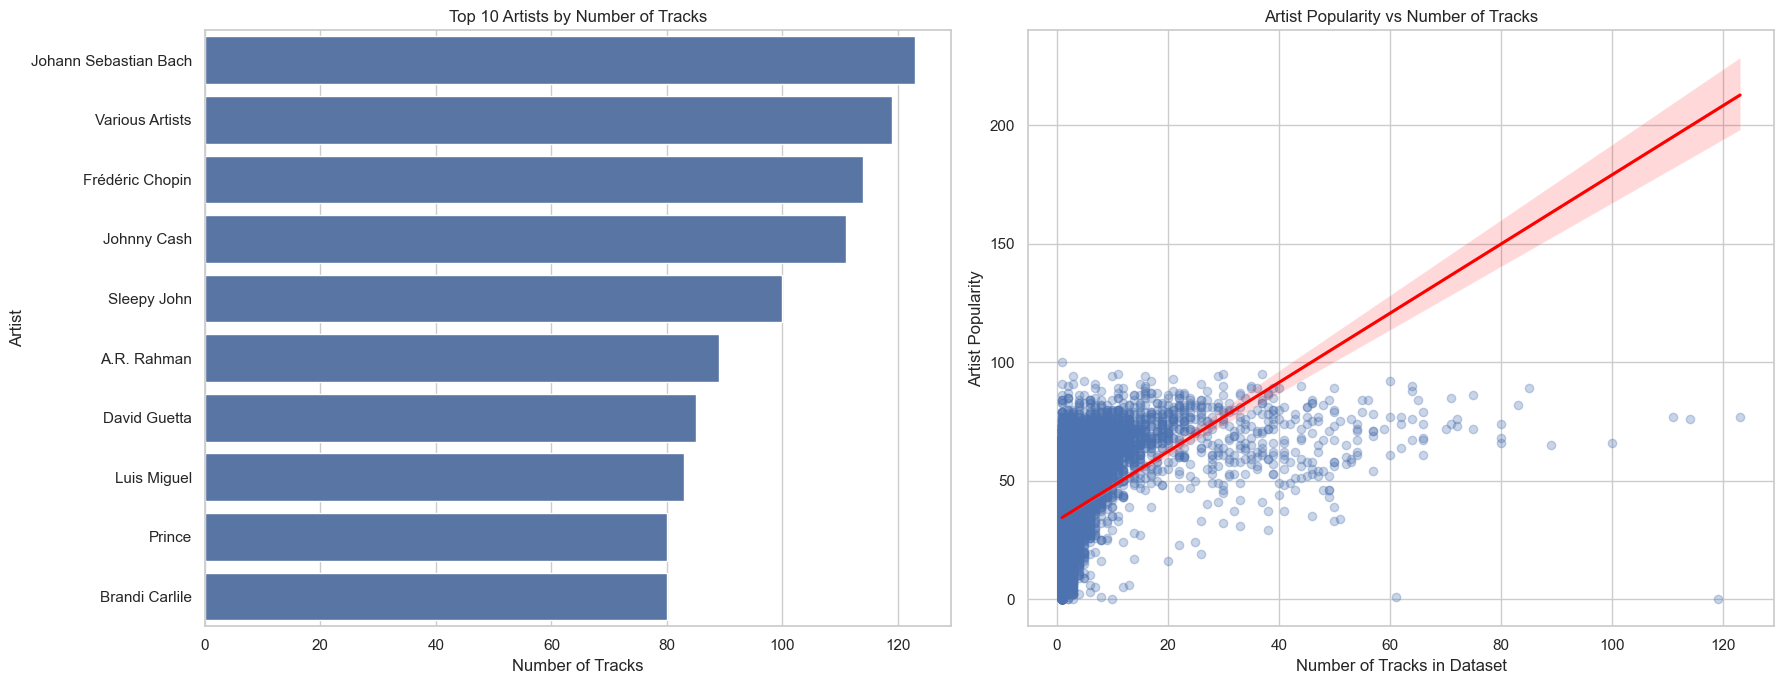

Correlation between number of tracks and artist popularity: 0.38


In [19]:
# Count how many unique tracks each artist has
artist_track_counts = (
    df_tracks
    .groupby("artist_name")["track_id"]
    .nunique()
    .reset_index(name="track_count")
)

# Get artist popularity
artist_popularity = (
    df_tracks
    .groupby("artist_name")["artist_popularity"]
    .max()
    .reset_index()
)

# Merge track count and popularity
artist_analysis = artist_track_counts.merge(
    artist_popularity,
    on="artist_name",
    how="left"
)

# oremove extreme values
# artist_analysis = artist_analysis[artist_analysis["track_count"] <= 200].copy()


# Top 10 artists by number of tracks
top_artists_by_tracks = (
    artist_analysis
    .sort_values("track_count", ascending=False)
    .head(10)
)

# Create 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 artists by number of tracks
sns.barplot(
    data=top_artists_by_tracks,
    x="track_count",
    y="artist_name",
    ax=axes[0]
)

axes[0].set_title("Top 10 Artists by Number of Tracks")
axes[0].set_xlabel("Number of Tracks")
axes[0].set_ylabel("Artist")

# Artist popularity vs number of tracks
sns.regplot(
    data=artist_analysis,
    x="track_count",
    y="artist_popularity",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1]
)

axes[1].set_title("Artist Popularity vs Number of Tracks")
axes[1].set_xlabel("Number of Tracks in Dataset")
axes[1].set_ylabel("Artist Popularity")

plt.tight_layout()
plt.show()

# Correlation
correlation = artist_analysis["track_count"].corr(
    artist_analysis["artist_popularity"]
)

print(f"Correlation between number of tracks and artist popularity: {correlation:.2f}")

### 5.3. Top artists by followers vs. Popularity

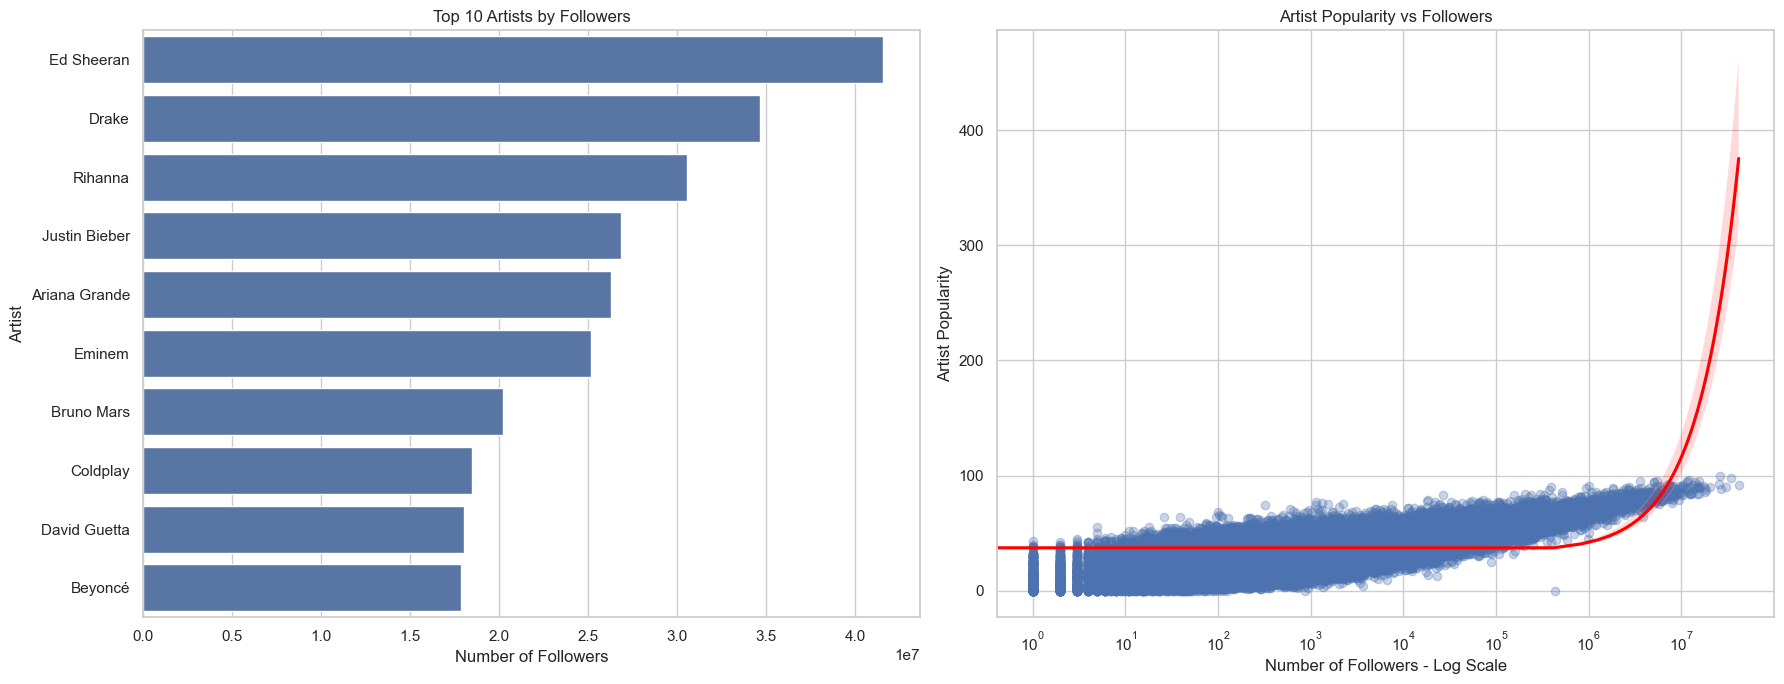

In [20]:
# Top 10 artists by followers
top_artists_by_followers = (
    df_artists
    .sort_values("followers", ascending=False)
    [["artist_name", "followers", "artist_popularity"]]
    .head(10)
)

# Create 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=top_artists_by_followers,
    x="followers",
    y="artist_name",
    ax=axes[0]
)

axes[0].set_title("Top 10 Artists by Followers")
axes[0].set_xlabel("Number of Followers")
axes[0].set_ylabel("Artist")

# Artist popularity vs followers

sns.regplot(
    data=df_artists,
    x="followers",
    y="artist_popularity",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[1]
)

axes[1].set_xscale("log")
axes[1].set_title("Artist Popularity vs Followers")
axes[1].set_xlabel("Number of Followers - Log Scale")
axes[1].set_ylabel("Artist Popularity")

plt.tight_layout()
plt.show()


## 6. Research Findings: Recommendation Model Options

Based on the dataset of approximately 100,000 tracks and the selected Spotify audio features, the recommendation system will focus on content-based approaches. Since no user interaction data, ratings, likes, or listening history are available, the models should recommend songs based on audio similarity rather than user behavior.

### Option A: Content-Based Filtering using Cosine Similarity
- **Concept**: Represent each track as a vector of selected audio features and calculate cosine similarity between the input song and all other tracks.
- **Pros**: Simple, explainable, scalable, and suitable when no user interaction data is available. It works well for recommending songs with a similar audio profile.
- **Cons**: May recommend songs that are very similar and may lack diversity or serendipity.
- **Implementation**: Scale the selected audio features and use cosine similarity to rank tracks by similarity score.

### Option B: K-Nearest Neighbors (KNN)
- **Concept**: Find the tracks that are closest to the input song in the scaled audio feature space using a distance metric such as cosine or Euclidean distance.
- **Pros**: Easy to understand, directly matches the goal of finding similar songs, and can be tuned by changing the number of neighbors or distance metric.
- **Cons**: Can become slower at query time for larger datasets if no indexing or approximate nearest neighbor method is used.
- **Implementation**: Use `scikit-learn`’s `NearestNeighbors` on the scaled audio feature matrix.

--- 

## 7. Potential Issues & Limitations
1. New songs without audio feature extraction cannot be recommended.
2. **Feature Scaling**: Numerical features (Tempo vs. Acousticness) have different scales and must be normalized before distance calculations.
3. **Popularity Bias**: Models might over-recommend the most popular artists (e.g., Ariana Grande, Drake) if popularity is included as a feature.

## 8. Next Steps

1. Implement a Feature Scaling pipeline.
2. Prototype a Content-Based Recommender using Cosine Similarity.
3. Build a Streamlit demo for real-time interaction.